STUDENT PERFORMANCE PREDICTION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    GridSearchCV,
    learning_curve
)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
print(df.head)

<bound method NDFrame.head of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none      

In [ ]:
print(df.columns)
print("\n")
print(df.info())
print("\n")
print(df.isnull().sum())

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


gender                         0
race/ethnicity                 0
parental lev

Create Pass/Fail target using average score.

In [ ]:
df['average_score']=(
    df['math score']+
    df['reading score']+
    df['writing score']
)/3
df['result']= df['average_score'].apply(lambda x:1 if x>=50 else 0)

df[["math score","reading score","writing score",'average_score','result']].head()

,math score,reading score,writing score,average_score,result
0,72,72,74,72.666667,1
1,69,90,88,82.333333,1
2,90,95,93,92.666667,1
3,47,57,44,49.333333,0
4,76,78,75,76.333333,1


ENCODE CATEGORICAL VALUES

In [ ]:
df_encoded = df.copy()

label_encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in categorical_columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

df_encoded.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_Score,average_score,result
0,0,1,1,1,1,72,72,74,72.666667,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,76.333333,1


In [ ]:
X = df_encoded[
    [
        "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course",
        "math score",
        "reading score",
        "writing score"
    ]
]

y = df_encoded["result"]

print(X.head())
print(y.head())

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  
0                        1          72             72             74  
1                        0          69             90             88  
2                        1          90             95             93  
3                        1          47             57             44  
4                        1          76             78             75  
0    1
1    1
2    1
3    0
4    1
Name: result, dtype: int64


TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 800
Testing records: 200


Train Logistic Regression, Decision Tree, and Random Forest.

In [ ]:
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000)
)

lr_model.fit(X_train, y_train)

lr_train_preds = lr_model.predict(X_train)
lr_test_preds = lr_model.predict(X_test)

lr_train_acc = accuracy_score(y_train, lr_train_preds)
lr_test_acc = accuracy_score(y_test, lr_test_preds)

print("Training Accuracy:", lr_train_acc)
print("Testing Accuracy:", lr_test_acc)

Training Accuracy: 0.99375
Testing Accuracy: 0.985


In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.985


In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_train_preds = rf_model.predict(X_train)
rf_test_preds = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_preds)
rf_test_acc = accuracy_score(y_test, rf_test_preds)

print("Training Accuracy:", rf_train_acc)
print("Testing Accuracy:", rf_test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.995


Compare accuracy, precision, recall, and F1-score.




In [ ]:
from sklearn.metrics import classification_report

models = {
    "Decision Tree": model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model
}

# Print the report for each model
for name, clf in models.items():
    print(f"\n {name} EVALUATION")
    preds = clf.predict(X_test)
    print(classification_report(y_test, preds, zero_division=0))


 Decision Tree EVALUATION
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.99      0.99      0.99       173

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200


 Random Forest EVALUATION
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.99      1.00      1.00       173

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200


 Logistic Regression EVALUATION
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        27
           1       0.98      1.00      0.99       173

    accuracy                           0.98       200
   macro avg       0.99      0.94      0.

Apply 5 Fold Cross Validation

In [ ]:
cv_model = DecisionTreeClassifier(max_depth=3, random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Average Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.965 0.965 0.97  0.98  0.985]
Average Cross Validation Accuracy: 0.9730000000000001


BEST PARAMETERS

In [ ]:
param_grid = {
    "max_depth": [1, 2, 3, 4, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best Cross Validation Accuracy: 0.9780000000000001


TUNE DECISION TREE HYPERPARAMETERS

In [ ]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

best_predictions = best_model.predict(X_test)

print("Tuned Model Testing Accuracy:", accuracy_score(y_test, best_predictions))

print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Tuned Model Testing Accuracy: 0.985

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.99      0.99      0.99       173

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200



TUNE RANDOM FOREST HYPERPARAMETERS

In [ ]:
rf_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X, y)
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Accuracy:", rf_grid.best_score_)


Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Random Forest CV Accuracy: 0.9890000000000001


LEARNING CURVE

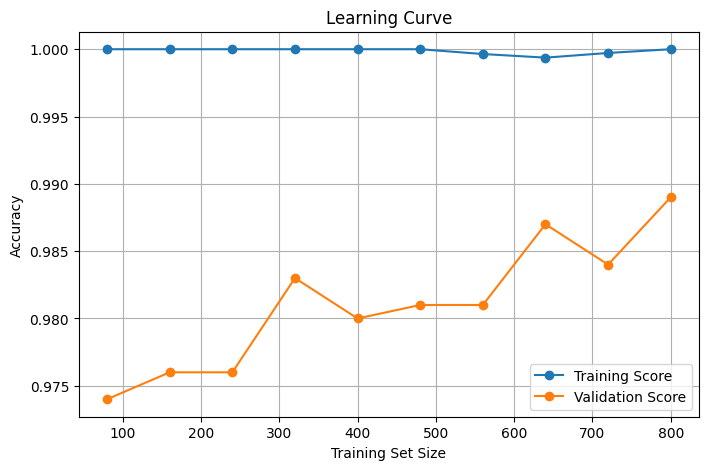

In [ ]:
final_model = rf_grid.best_estimator_

train_sizes, train_scores, validation_scores = learning_curve(
    final_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
plt.plot(train_sizes, validation_mean, marker="o", label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()